# Track training (local)

Reads the JSONL metrics sidecars that `train_pipeline/train_head.py` writes next to its `--output` (e.g. `trained_heads/mlp_sum/model.metrics.jsonl`) and plots per-trait train/val curves — no wandb cloud connection needed.

Set `MODEL_PATHS` (the runs to compare) and `TRAITS` (the traits to plot) in the next cell. Each trait gets its own row of (MSE, PCC) panels; within a panel every run is a distinct color, with **train dashed** and **val a bold solid line in the same color**.

Each JSONL line is one logged row: `train/*` rows on a step cadence, `val/*` rows once per epoch. Run the **live follow** cell to watch runs as they train.

In [2]:
import json
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output

# List the runs you want to compare (paths relative to repo root). Each is a
# JSONL metrics sidecar written next to a train_head.py --output.
import os
base_dir = "../trained_heads/sweep"
MODEL_PATHS = [f"{base_dir}/{s}/model.metrics.jsonl" for s in os.listdir(base_dir)]
sweep_dir = "../trained_heads/sweep_refdelta"
MODEL_PATHS += [f"{base_dir}/{s}/model.metrics.jsonl" for s in os.listdir(sweep_dir)]
# MODEL_PATHS = [
#     Path("../trained_heads/linear_sum/model.metrics.jsonl"),
#     Path("../trained_heads/mlp_sum/model.metrics.jsonl"),
#     Path("../trained_heads/mlp_sum/model_snponly.metrics.jsonl"),

#     # Path("../trained_encoder/linear_sum/model.metrics.jsonl"),
# ]
print(MODEL_PATHS)

# Traits to plot, one row of (MSE, PCC) panels each.
EVAL_TRAITS = [
    "Alkali spreading value",
    "Amylose content",
    "Panicle number per plant",
    "Protein content",
    "Seed length",
    "Seed number per panicle",
]

def load_metrics(path):
    """Read the JSONL sidecar into a DataFrame, tolerating a half-written
    final line (the trainer may be mid-flush when we read)."""
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                continue  # partial last line during a live write
    return pd.DataFrame(rows)


def load_all(model_paths):
    """Load every run into a {label: DataFrame} dict, labelled by run dir."""
    out = {}
    for p in model_paths:
        p = Path(p)
        label = p.parent.name
        if label in out:  # disambiguate runs sharing a dir
            label = f"{p.parent.name}/{p.stem}"
        out[label] = load_metrics(p)
    return out


def plot_traits(metrics_by_model, traits):
    """One row of (MSE, PCC) panels per trait. Each run gets its own color;
    train is dashed, val is a bold solid line in the same color."""
    n = len(traits)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n), squeeze=False)
    cmap = plt.get_cmap("tab10")
    colors = {name: cmap(i % 10) for i, name in enumerate(metrics_by_model)}
    for row, trait in enumerate(traits):
        for ax, metric in [(axes[row][0], "mse"), (axes[row][1], "pcc")]:
            for name, df in metrics_by_model.items():
                color = colors[name]
                for split, ls, lw, alpha in [
                    ("train", "--", 1.5, 0.7),
                    ("val", "-", 2.5, 1.0),
                ]:
                    col = f"{split}/{metric}/{trait}"
                    if col not in df.columns:
                        continue
                    sub = df.dropna(subset=[col, "step"])
                    if len(sub):
                        ax.plot(sub["step"], sub[col], linestyle=ls,
                                linewidth=lw, alpha=alpha, color=color,
                                label=f"{name} {split}")
            ax.set(xlabel="step", ylabel=metric, title=f"{trait} — {metric}")
            ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

['../trained_heads/sweep/linear_hw250/model.metrics.jsonl', '../trained_heads/sweep/linear_hw500/model.metrics.jsonl', '../trained_heads/sweep/mlp_hw1000_snponly/model.metrics.jsonl', '../trained_heads/sweep/linear_hw1000_snponly/model.metrics.jsonl', '../trained_heads/sweep/linear_hw1000/model.metrics.jsonl', '../trained_heads/sweep/mlp_hw250/model.metrics.jsonl', '../trained_heads/sweep/mlp_hw1000/model.metrics.jsonl', '../trained_heads/sweep/linear_hw500_snponly/model.metrics.jsonl', '../trained_heads/sweep/linear_hw250_snponly/model.metrics.jsonl', '../trained_heads/sweep/mlp_hw500_snponly/model.metrics.jsonl', '../trained_heads/sweep/mlp_hw250_snponly/model.metrics.jsonl', '../trained_heads/sweep/mlp_hw500/model.metrics.jsonl', '../trained_heads/sweep/linear_hw250/model.metrics.jsonl', '../trained_heads/sweep/linear_hw500/model.metrics.jsonl', '../trained_heads/sweep/linear_hw250_snponly/model.metrics.jsonl', '../trained_heads/sweep/mlp_hw250_snponly/model.metrics.jsonl', '../trai

## Static snapshot
Load and plot whatever has been logged so far.

In [5]:
metrics_by_model = load_all(MODEL_PATHS)

# Latest logged val PCC per model x trait.
summary = pd.DataFrame({
    name: {
        trait: df[f"val/pcc/{trait}"].dropna().iloc[-1]
        for trait in EVAL_TRAITS
        if f"val/pcc/{trait}" in df.columns and df[f"val/pcc/{trait}"].notna().any()
    }
    for name, df in metrics_by_model.items()
})
print("latest val PCC")
print(summary)

latest val PCC
                          linear_hw250  linear_hw500  mlp_hw1000_snponly  \
Alkali spreading value        0.419535      0.539927            0.362563   
Amylose content               0.632260      0.717165            0.868152   
Panicle number per plant      0.689433      0.693912            0.733268   
Protein content               0.250746      0.462134            0.489052   
Seed length                   0.548069      0.496116            0.631971   
Seed number per panicle       0.171785      0.315937            0.360643   

                          linear_hw1000_snponly  linear_hw1000  mlp_hw250  \
Alkali spreading value                 0.399818       0.401207   0.366688   
Amylose content                        0.721931       0.630988   0.788089   
Panicle number per plant               0.754229       0.727655   0.723028   
Protein content                        0.401963       0.394410   0.416699   
Seed length                            0.599160       0.618519   0.

linear_hw250: 125 rows · steps 0-500
linear_hw500: 125 rows · steps 0-500
mlp_hw1000_snponly: 125 rows · steps 0-500
linear_hw1000_snponly: 125 rows · steps 0-500
linear_hw1000: 125 rows · steps 0-500
mlp_hw250: 125 rows · steps 0-500
mlp_hw1000: 125 rows · steps 0-500
linear_hw500_snponly: 125 rows · steps 0-500
linear_hw250_snponly: 125 rows · steps 0-500
mlp_hw500_snponly: 125 rows · steps 0-500
mlp_hw250_snponly: 125 rows · steps 0-500
mlp_hw500: 125 rows · steps 0-500


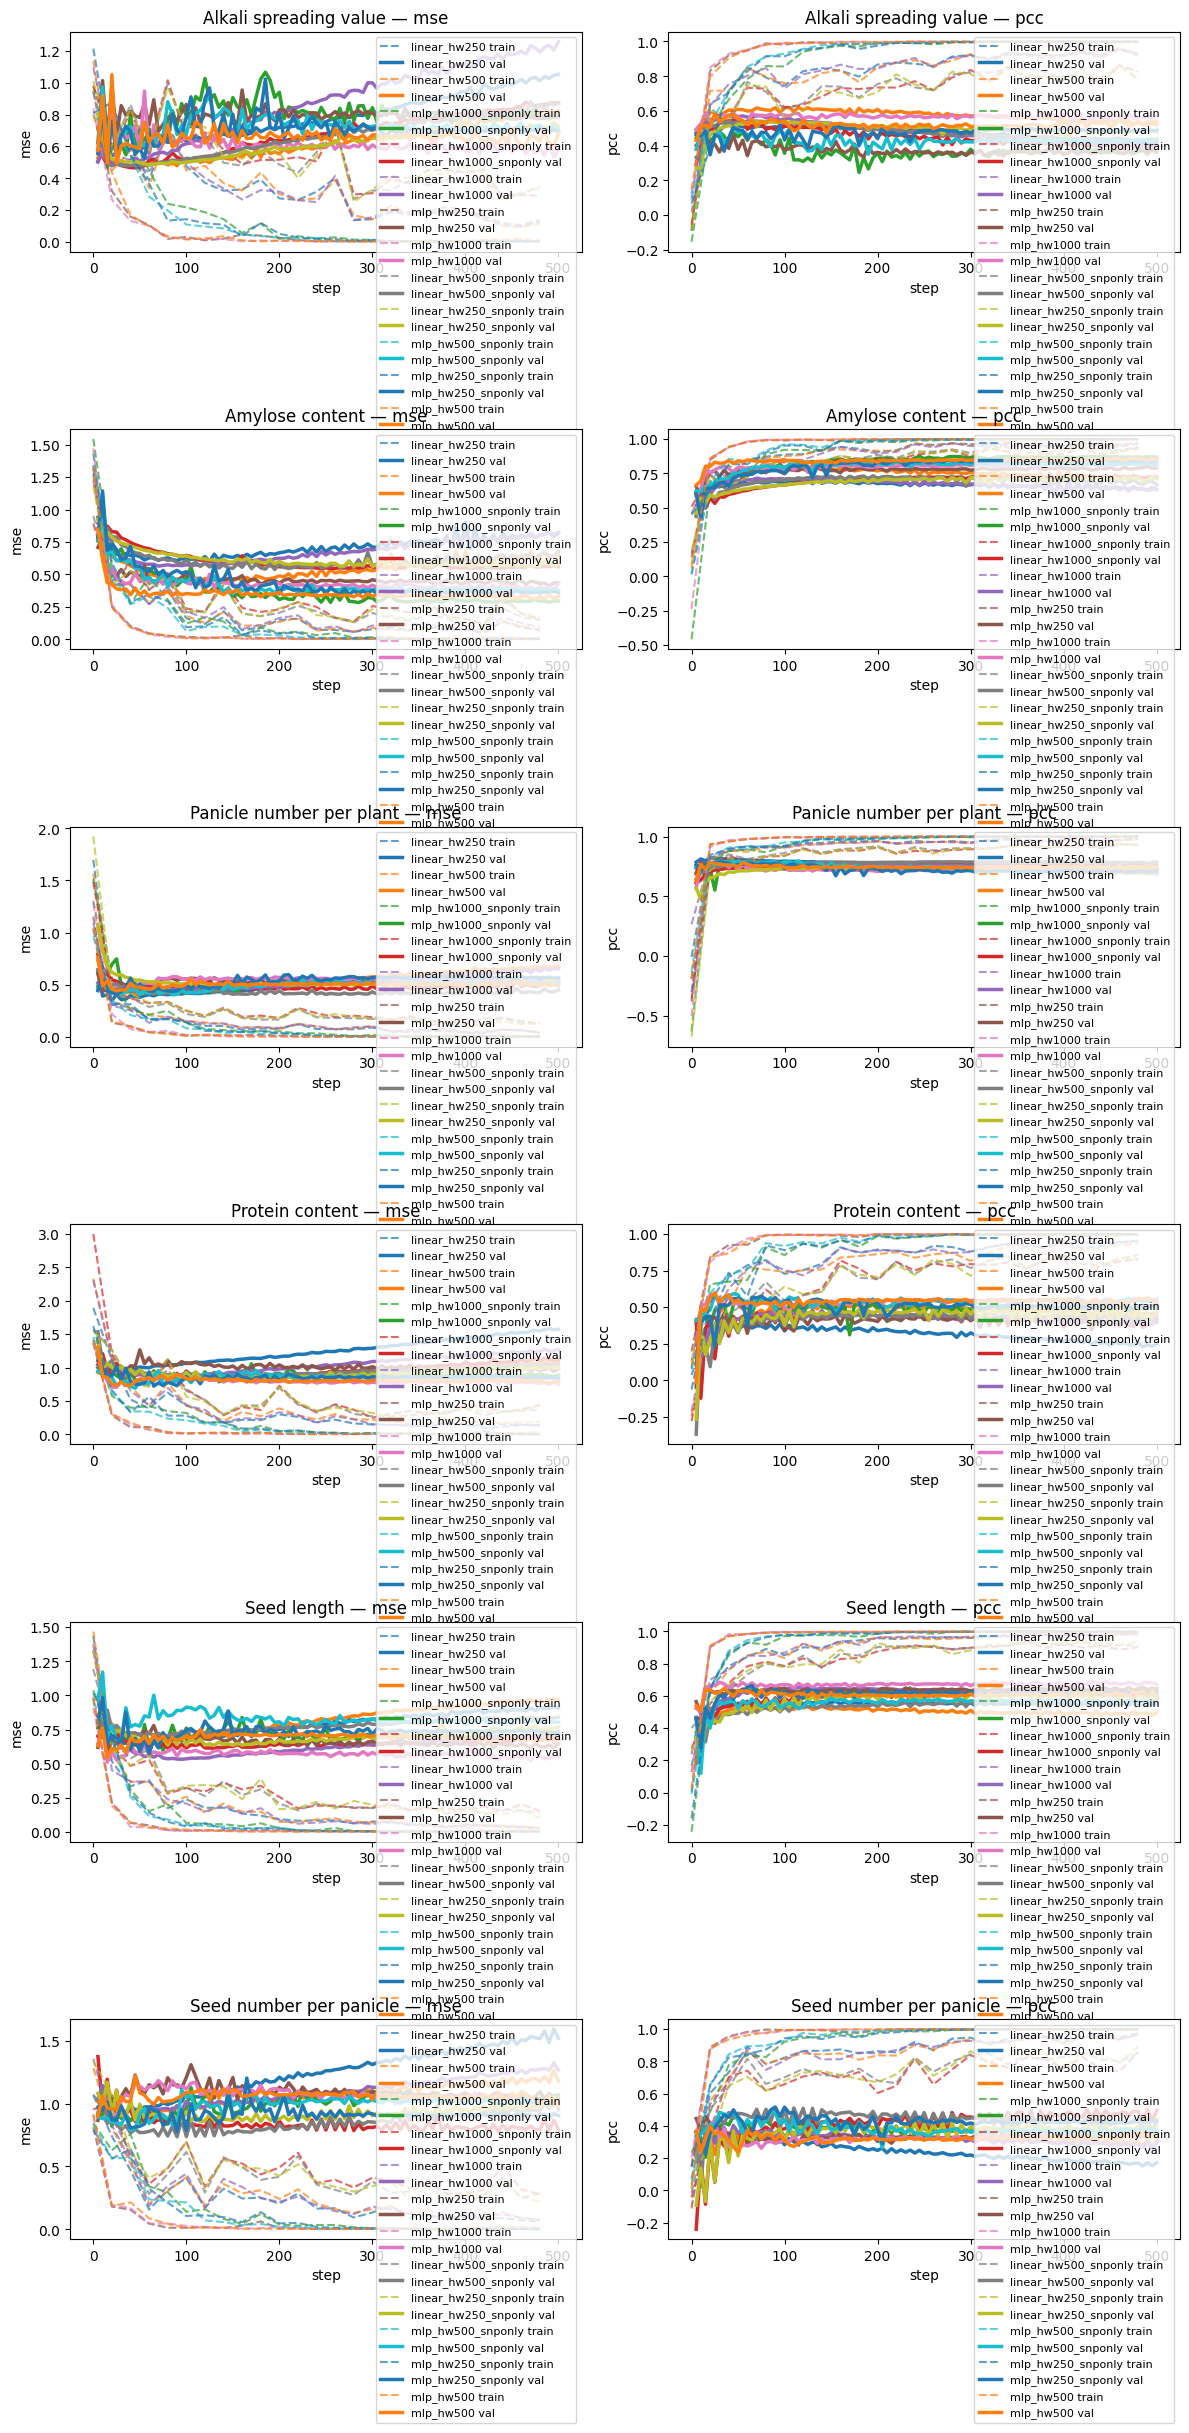

In [6]:
for name, df in metrics_by_model.items():
    print(f"{name}: {len(df)} rows · steps {df['step'].min()}-{df['step'].max()}")
plot_traits(metrics_by_model, EVAL_TRAITS)

## Live follow
Re-reads the file and redraws every few seconds. Interrupt the kernel (■ / `Ctrl-C`) to stop.

In [ ]:
REFRESH_SEC = 5

try:
    while True:
        metrics_by_model = load_all(MODEL_PATHS)
        clear_output(wait=True)
        plot_traits(metrics_by_model, TRAITS)
        last = max((int(df["step"].max()) for df in metrics_by_model.values() if len(df)), default=None)
        print(f"{len(metrics_by_model)} runs · last step {last} · refreshing every {REFRESH_SEC}s (interrupt to stop)")
        time.sleep(REFRESH_SEC)
except KeyboardInterrupt:
    print("stopped following")